In [ ]:
# importng basic lib.
import pandas as pd
import numpy as np
preheater_data= pd.read_csv('/content/data(internship-data-1).csv')


In [ ]:
# shows descriptn of my csv data
print(preheater_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378719 entries, 0 to 378718
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   time                      377719 non-null  object
 1   Cyclone_Inlet_Gas_Temp    377719 non-null  object
 2   Cyclone_Material_Temp     377719 non-null  object
 3   Cyclone_Outlet_Gas_draft  377719 non-null  object
 4   Cyclone_cone_draft        377719 non-null  object
 5   Cyclone_Gas_Outlet_Temp   377719 non-null  object
 6   Cyclone_Inlet_Draft       377719 non-null  object
dtypes: object(7)
memory usage: 20.2+ MB
None


In [ ]:
print(preheater_data.describe())

                  time Cyclone_Inlet_Gas_Temp Cyclone_Material_Temp  \
count           377719                 377719                377719   
unique          377719                  39736                 39662   
top     8/7/2020 12:15            Not Connect                     0   
freq                 1                    723                 14226   

       Cyclone_Outlet_Gas_draft Cyclone_cone_draft Cyclone_Gas_Outlet_Temp  \
count                    377719             377719                  377719   
unique                    27669              26487                   48044   
top                 Not Connect        Not Connect                   28.88   
freq                        723                723                    2036   

       Cyclone_Inlet_Draft  
count               377719  
unique               24010  
top            Not Connect  
freq                   723  


In [ ]:
data= preheater_data.copy()
print(data.head())    # this I use to get first 5 DATA for ovrview

            time Cyclone_Inlet_Gas_Temp Cyclone_Material_Temp  \
0  1/1/2017 0:00                 867.63                910.42   
1  1/1/2017 0:05                 879.23                918.14   
2  1/1/2017 0:10                 875.67                924.18   
3  1/1/2017 0:15                 875.28                923.15   
4  1/1/2017 0:20                 891.66                934.26   

  Cyclone_Outlet_Gas_draft Cyclone_cone_draft Cyclone_Gas_Outlet_Temp  \
0                  -189.54            -186.04                  852.13   
1                  -184.33             -182.1                  862.53   
2                  -181.26            -166.47                  866.06   
3                  -179.15            -174.83                  865.85   
4                  -178.32            -173.72                  876.06   

  Cyclone_Inlet_Draft  
0              -145.9  
1             -149.76  
2             -145.01  
3             -142.82  
4             -143.39  


In [ ]:
df = pd.DataFrame(data)
print(df)  # ovrview

                 time Cyclone_Inlet_Gas_Temp Cyclone_Material_Temp  \
0       1/1/2017 0:00                 867.63                910.42   
1       1/1/2017 0:05                 879.23                918.14   
2       1/1/2017 0:10                 875.67                924.18   
3       1/1/2017 0:15                 875.28                923.15   
4       1/1/2017 0:20                 891.66                934.26   
...               ...                    ...                   ...   
378714            NaN                    NaN                   NaN   
378715            NaN                    NaN                   NaN   
378716            NaN                    NaN                   NaN   
378717            NaN                    NaN                   NaN   
378718            NaN                    NaN                   NaN   

       Cyclone_Outlet_Gas_draft Cyclone_cone_draft Cyclone_Gas_Outlet_Temp  \
0                       -189.54            -186.04                  852.13   
1  

## data cleaning process

In [ ]:
# Checkd for missing data
print(data.isnull().sum())

time                        1000
Cyclone_Inlet_Gas_Temp      1000
Cyclone_Material_Temp       1000
Cyclone_Outlet_Gas_draft    1000
Cyclone_cone_draft          1000
Cyclone_Gas_Outlet_Temp     1000
Cyclone_Inlet_Draft         1000
dtype: int64


In [ ]:
# As there are null values so I have to clean the data
# Checking for indices  where it is null
null_indices= df.isnull()

In [ ]:
print(null_indices==True)

         time  Cyclone_Inlet_Gas_Temp  Cyclone_Material_Temp  \
0       False                   False                  False   
1       False                   False                  False   
2       False                   False                  False   
3       False                   False                  False   
4       False                   False                  False   
...       ...                     ...                    ...   
378714   True                    True                   True   
378715   True                    True                   True   
378716   True                    True                   True   
378717   True                    True                   True   
378718   True                    True                   True   

        Cyclone_Outlet_Gas_draft  Cyclone_cone_draft  Cyclone_Gas_Outlet_Temp  \
0                          False               False                    False   
1                          False               False                 

In [ ]:
#  checkng Row indices where at least 1 col. is null
rows_with_nulls = df[df.isnull().any(axis=1)].index.tolist()
print(f"\nRow indices with any null value: {rows_with_nulls}")


Row indices with any null value: [377719, 377720, 377721, 377722, 377723, 377724, 377725, 377726, 377727, 377728, 377729, 377730, 377731, 377732, 377733, 377734, 377735, 377736, 377737, 377738, 377739, 377740, 377741, 377742, 377743, 377744, 377745, 377746, 377747, 377748, 377749, 377750, 377751, 377752, 377753, 377754, 377755, 377756, 377757, 377758, 377759, 377760, 377761, 377762, 377763, 377764, 377765, 377766, 377767, 377768, 377769, 377770, 377771, 377772, 377773, 377774, 377775, 377776, 377777, 377778, 377779, 377780, 377781, 377782, 377783, 377784, 377785, 377786, 377787, 377788, 377789, 377790, 377791, 377792, 377793, 377794, 377795, 377796, 377797, 377798, 377799, 377800, 377801, 377802, 377803, 377804, 377805, 377806, 377807, 377808, 377809, 377810, 377811, 377812, 377813, 377814, 377815, 377816, 377817, 377818, 377819, 377820, 377821, 377822, 377823, 377824, 377825, 377826, 377827, 377828, 377829, 377830, 377831, 377832, 377833, 377834, 377835, 377836, 377837, 377838, 37783

In [ ]:
# So in excel data entry has been made from row no .2 and here pandas start entry from 0 ,1,2,3.....
# That's why empty row start from 377719 row here
# so I have to drop 1000 rows from 377719 to 378718 as they doen't belong to main data

In [ ]:
df.drop(df.index[377719:378718],axis=0,inplace = True)  # droped row with empty val.

In [ ]:
print(df.isnull().sum()) # so empty rows has been dropped

time                        1
Cyclone_Inlet_Gas_Temp      1
Cyclone_Material_Temp       1
Cyclone_Outlet_Gas_draft    1
Cyclone_cone_draft          1
Cyclone_Gas_Outlet_Temp     1
Cyclone_Inlet_Draft         1
dtype: int64


 Detecting error strings in each column

In [ ]:

# All sensor columns except time
sensor_cols = [c for c in df.columns if c.lower() != "time"]

#  error keywords uptill now finded
error_keywords = [
    "timeout", "not connect", "scan timeout", "configure",
    "comm fail", "unit down"
]

print("=> Error entry Report  finded  ===\n")

for col in sensor_cols:
    unique_vals = df[col].astype(str).str.lower().unique()

    # Find values that contain error strings
    errors_found = [u for u in unique_vals if any(k in u for k in error_keywords)]

    if errors_found:
        print(f"Column: {col}")
        print(f"  Error-like entries are there:")
        for val in errors_found:
            count = (df[col].astype(str).str.lower() == val).sum()
            print(f"    {val}  -->  {count} rows")
        print()

=> Error entry Report  finded  ===

Column: Cyclone_Inlet_Gas_Temp
  Error-like entries are there:
    i/o timeout  -->  470 rows
    not connect  -->  723 rows
    scan timeout  -->  17 rows
    configure  -->  108 rows
    comm fail  -->  2 rows

Column: Cyclone_Material_Temp
  Error-like entries are there:
    i/o timeout  -->  470 rows
    unit down  -->  271 rows
    not connect  -->  723 rows
    scan timeout  -->  17 rows
    configure  -->  108 rows
    comm fail  -->  2 rows

Column: Cyclone_Outlet_Gas_draft
  Error-like entries are there:
    i/o timeout  -->  470 rows
    not connect  -->  723 rows
    scan timeout  -->  17 rows
    configure  -->  108 rows
    unit down  -->  1 rows
    comm fail  -->  2 rows

Column: Cyclone_cone_draft
  Error-like entries are there:
    i/o timeout  -->  470 rows
    not connect  -->  723 rows
    scan timeout  -->  17 rows
    configure  -->  108 rows
    comm fail  -->  2 rows

Column: Cyclone_Gas_Outlet_Temp
  Error-like entries are th

In [ ]:
# creating copy of df , so if problm exist then can move back
df_clean= df.copy()

# **EISHAAN**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Start with your cleaned dataframe
# (I'm assuming you already have df_clean from your code)
df1 = df_clean.copy()  # Work on a copy

# Make sure time is datetime and sorted
df1['time'] = pd.to_datetime(df1['time'])
df1 = df1.sort_values('time').reset_index(drop=True)

print("Original columns:", df1.columns.tolist())
print("Original shape:", df1.shape)


Original columns: ['time', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']
Original shape: (377720, 7)


In [ ]:
df1[
    ['Cyclone_Inlet_Draft',
     'Cyclone_Outlet_Gas_draft',
     'Cyclone_cone_draft',
     'Cyclone_Inlet_Gas_Temp',
     'Cyclone_Material_Temp',
     'Cyclone_Gas_Outlet_Temp']
].dtypes


,0
Cyclone_Inlet_Draft,object
Cyclone_Outlet_Gas_draft,object
Cyclone_cone_draft,object
Cyclone_Inlet_Gas_Temp,object
Cyclone_Material_Temp,object
Cyclone_Gas_Outlet_Temp,object


In [ ]:
num_cols = [
    'Cyclone_Inlet_Draft',
    'Cyclone_Outlet_Gas_draft',
    'Cyclone_cone_draft',
    'Cyclone_Inlet_Gas_Temp',
    'Cyclone_Material_Temp',
    'Cyclone_Gas_Outlet_Temp'
]

for c in num_cols:
    df1[c] = (
        df1[c]
        .astype(str)                        # convert to string
        .str.replace(',', '')               # remove commas
        .str.replace('NA', '', case=False)  # remove NA
        .str.replace('-', '')               # remove hyphens
        .str.strip()                        # remove spaces
    )
    df1[c] = pd.to_numeric(df1[c], errors='coerce')  # convert to numbers


In [ ]:
# ============================================
# PHYSICS FEATURES (Domain Knowledge)
# ============================================

print("\n🔧 Creating physics features...")

# 1. PRESSURE DROP (Critical for detecting clogs/blockages)
df1['Pressure_Drop_Inlet_Outlet'] = df1['Cyclone_Inlet_Draft'] - df1['Cyclone_Outlet_Gas_draft']
df1['Pressure_Drop_Cone_Outlet'] = df1['Cyclone_cone_draft'] - df1['Cyclone_Outlet_Gas_draft']

# 2. HEAT TRANSFER EFFICIENCY
df1['Heat_Transfer_Efficiency'] = df1['Cyclone_Inlet_Gas_Temp'] - df1['Cyclone_Material_Temp']

# 3. TEMPERATURE GRADIENT (Inlet vs Outlet)
df1['Temp_Gradient_Inlet_Outlet'] = df1['Cyclone_Inlet_Gas_Temp'] - df1['Cyclone_Gas_Outlet_Temp']

print("✅ Physics features created!")
print(f"New shape: {df1.shape}")
print(f"New columns: {df1.columns.tolist()[-4:]}")  # Show last 4 columns

# Let's see what these look like
print("\n📊 Sample of new physics features:")
print(df1[['time', 'Pressure_Drop_Inlet_Outlet', 'Heat_Transfer_Efficiency',
           'Temp_Gradient_Inlet_Outlet']].head(10))


🔧 Creating physics features...
✅ Physics features created!
New shape: (377720, 11)
New columns: ['Pressure_Drop_Inlet_Outlet', 'Pressure_Drop_Cone_Outlet', 'Heat_Transfer_Efficiency', 'Temp_Gradient_Inlet_Outlet']

📊 Sample of new physics features:
                 time  Pressure_Drop_Inlet_Outlet  Heat_Transfer_Efficiency  \
0 2017-01-01 00:00:00                      -43.64                    -42.79   
1 2017-01-01 00:05:00                      -34.57                    -38.91   
2 2017-01-01 00:10:00                      -36.25                    -48.51   
3 2017-01-01 00:15:00                      -36.33                    -47.87   
4 2017-01-01 00:20:00                      -34.93                    -42.60   
5 2017-01-01 00:25:00                      -41.45                    -53.84   
6 2017-01-01 00:30:00                      -32.37                    -45.38   
7 2017-01-01 00:35:00                      -34.50                    -61.80   
8 2017-01-01 00:40:00                  

In [ ]:
# ============================================
# TEMPORAL FEATURES (Time-Series Context)
# ============================================

print("\n⏰ Creating temporal features...")

# Define your 6 original sensor columns
sensor_cols = [
    'Cyclone_Inlet_Gas_Temp',
    'Cyclone_Material_Temp',
    'Cyclone_Outlet_Gas_draft',
    'Cyclone_cone_draft',
    'Cyclone_Gas_Outlet_Temp',
    'Cyclone_Inlet_Draft'
]

# For EACH sensor, create 3 temporal features
for col in sensor_cols:
    print(f"  Processing {col}...")

    # 1. RATE OF CHANGE (How fast is it changing?)
    df1[f'{col}_RateOfChange'] = df1[col].diff()

    # 2. ROLLING VOLATILITY (How unstable is it?)
    # Window=12 means 1 hour (12 * 5min = 60min)
    df1[f'{col}_Volatility_1h'] = df1[col].rolling(window=12, min_periods=1).std()

    # 3. DEVIATION FROM MOVING AVERAGE
    rolling_mean = df1[col].rolling(window=12, min_periods=1).mean()
    df1[f'{col}_Deviation'] = df1[col] - rolling_mean

print("\n✅ Temporal features created!")
print(f"New shape: {df1.shape}")
print(f"Total columns now: {len(df1.columns)}")

# Check for any NaN created
print(f"\nNaN count per column:")
print(df1.isnull().sum()[df1.isnull().sum() > 0])


⏰ Creating temporal features...
  Processing Cyclone_Inlet_Gas_Temp...
  Processing Cyclone_Material_Temp...
  Processing Cyclone_Outlet_Gas_draft...
  Processing Cyclone_cone_draft...
  Processing Cyclone_Gas_Outlet_Temp...
  Processing Cyclone_Inlet_Draft...

✅ Temporal features created!
New shape: (377720, 29)
Total columns now: 29

NaN count per column:
time                                         1
Cyclone_Inlet_Gas_Temp                    1321
Cyclone_Material_Temp                     1592
Cyclone_Outlet_Gas_draft                  1322
Cyclone_cone_draft                        1321
Cyclone_Gas_Outlet_Temp                   1322
Cyclone_Inlet_Draft                       1323
Pressure_Drop_Inlet_Outlet                1324
Pressure_Drop_Cone_Outlet                 1322
Heat_Transfer_Efficiency                  1592
Temp_Gradient_Inlet_Outlet                1322
Cyclone_Inlet_Gas_Temp_RateOfChange       1401
Cyclone_Inlet_Gas_Temp_Volatility_1h       980
Cyclone_Inlet_Gas_Temp_Devia

In [ ]:
# ============================================
# CLEAN UP NaN VALUES
# ============================================

print("\n🧹 Cleaning NaN values...")
print(f"Total rows before cleanup: {len(df1)}")
print(f"Total NaN values: {df1.isnull().sum().sum()}")

# Strategy: Drop rows with NaN (they're mostly from the beginning due to rolling windows)
df1_clean = df1.dropna().reset_index(drop=True)

print(f"\n✅ Cleanup complete!")
print(f"Rows after cleanup: {len(df1_clean)}")
print(f"Rows removed: {len(df1) - len(df1_clean)}")
print(f"Remaining NaN: {df1_clean.isnull().sum().sum()}")

# Verify we still have enough data
print(f"\nData retention: {len(df1_clean)/len(df1)*100:.2f}%")
print(f"Time range: {df1_clean['time'].min()} to {df1_clean['time'].max()}")


🧹 Cleaning NaN values...
Total rows before cleanup: 377720
Total NaN values: 36798

✅ Cleanup complete!
Rows after cleanup: 375770
Rows removed: 1950
Remaining NaN: 0

Data retention: 99.48%
Time range: 2017-01-01 00:05:00 to 2020-08-07 12:15:00


In [ ]:
# ============================================
# PREPARE FEATURES FOR MODELING
# ============================================

print("\n🎯 Preparing features for model training...")

# Select ALL numeric columns (exclude 'time')
feature_cols = [col for col in df1_clean.columns if col != 'time']

print(f"Total features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:5]}... (showing first 5)")

# Extract feature matrix
X = df1_clean[feature_cols].values

# Safety check: replace any inf values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Any NaN remaining? {np.isnan(X).sum()}")
print(f"Any Inf remaining? {np.isinf(X).sum()}")

# ============================================
# STANDARDIZE FEATURES
# ============================================

print("\n📏 Standardizing features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_scaled.shape}")
print(f"Mean of scaled data: {X_scaled.mean():.6f} (should be ~0)")
print(f"Std of scaled data: {X_scaled.std():.6f} (should be ~1)")

# ============================================
# TRAIN ISOLATION FOREST
# ============================================

print("\n🤖 Training Isolation Forest...")
print("Configuration:")
print("  - n_estimators: 300 (more trees = better detection)")
print("  - contamination: 0.02 (expect 2% anomalies)")
print("  - Using all CPU cores for speed")

iso = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=42,
    max_samples='auto',
    n_jobs=-1,  # Use all CPU cores
    verbose=1   # Show progress
)

# Fit the model
iso.fit(X_scaled)

print("\n✅ Model training complete!")

# ============================================
# GET PREDICTIONS
# ============================================

print("\n🔍 Making predictions...")

# Get anomaly scores (lower = more anomalous)
df1_clean['anomaly_score'] = iso.decision_function(X_scaled)

# Get binary labels (-1 = anomaly, 1 = normal)
predictions = iso.predict(X_scaled)
df1_clean['is_anomaly'] = (predictions == -1).astype(int)

print(f"\n✅ Predictions complete!")
print(f"Anomalies detected: {df1_clean['is_anomaly'].sum():,} points")
print(f"Anomaly rate: {df1_clean['is_anomaly'].mean()*100:.2f}%")

# Show distribution of anomaly scores
print("\nAnomaly score distribution:")
print(df1_clean['anomaly_score'].describe())


🎯 Preparing features for model training...
Total features: 28
Feature columns: ['Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp']... (showing first 5)

Feature matrix shape: (375770, 28)
Any NaN remaining? 0
Any Inf remaining? 0

📏 Standardizing features...
Scaled data shape: (375770, 28)
Mean of scaled data: 0.000000 (should be ~0)
Std of scaled data: 1.000000 (should be ~1)

🤖 Training Isolation Forest...
Configuration:
  - n_estimators: 300 (more trees = better detection)
  - contamination: 0.02 (expect 2% anomalies)
  - Using all CPU cores for speed


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    1.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    4.4s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    6.2s finished



✅ Model training complete!

🔍 Making predictions...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    3.7s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    5.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    4.2s



✅ Predictions complete!
Anomalies detected: 7,516 points
Anomaly rate: 2.00%

Anomaly score distribution:
count    375770.000000
mean          0.155483
std           0.050023
min          -0.193381
25%           0.144076
50%           0.170774
75%           0.186499
max           0.214824
Name: anomaly_score, dtype: float64


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    6.0s finished


In [ ]:
# ============================================
# APPLY SMOOTHING TO REDUCE NOISE
# ============================================

print("\n🎚️ Applying temporal smoothing...")
print("Why? Real anomalies last minutes/hours, not just 5-minute blips")

# Smooth anomaly scores over 30 minutes (6 timestamps)
df1_clean['anomaly_score_smoothed'] = df1_clean['anomaly_score'].rolling(
    window=6,
    min_periods=1
).mean()

# Re-classify based on smoothed scores
threshold = df1_clean['anomaly_score_smoothed'].quantile(0.02)
df1_clean['is_anomaly_smoothed'] = (df1_clean['anomaly_score_smoothed'] < threshold).astype(int)

print(f"✅ Smoothing complete!")
print(f"Smoothed threshold: {threshold:.6f}")
print(f"Smoothed anomalies: {df1_clean['is_anomaly_smoothed'].sum():,} points")
print(f"Difference: {df1_clean['is_anomaly_smoothed'].sum() - df1_clean['is_anomaly'].sum():+,} points")

# ============================================
# EXTRACT ANOMALY PERIODS
# ============================================

print("\n📅 Extracting continuous anomaly periods...")

# Get all smoothed anomaly points
anomalies = df1_clean[df1_clean['is_anomaly_smoothed'] == 1].copy()

if len(anomalies) > 0:
    # Group consecutive timestamps (gap > 15 minutes = new period)
    anomalies['time_diff'] = anomalies['time'].diff()
    anomalies['new_period'] = (anomalies['time_diff'] > pd.Timedelta(minutes=15)) | anomalies['time_diff'].isna()
    anomalies['period_id'] = anomalies['new_period'].cumsum()

    # Build period summary
    period_list = []
    for pid, group in anomalies.groupby('period_id'):
        start = group['time'].min()
        end = group['time'].max()
        duration = end - start
        n_points = len(group)

        # Get severity metrics
        max_score = group['anomaly_score_smoothed'].min()  # Lower = worse
        avg_score = group['anomaly_score_smoothed'].mean()

        period_list.append({
            'period_id': pid,
            'start_time': start,
            'end_time': end,
            'duration': duration,
            'n_points': n_points,
            'severity_max': max_score,
            'severity_avg': avg_score
        })

    periods_df = pd.DataFrame(period_list)

    # Filter out very short blips (< 20 minutes)
    periods_df = periods_df[periods_df['duration'] >= pd.Timedelta(minutes=20)]

    print(f"\n✅ Found {len(periods_df)} significant anomaly periods!")
    print(f"\nTop 10 longest periods:")
    print(periods_df.nlargest(10, 'duration')[['start_time', 'end_time', 'duration', 'n_points']])

    # Save results
    periods_df.to_csv("enhanced_anomaly_periods.csv", index=False)
    print(f"\n💾 Saved to: enhanced_anomaly_periods.csv")
else:
    print("No anomalies detected!")
    periods_df = None

# ============================================
# COMPARISON WITH ORIGINAL METHOD
# ============================================

print("\n📊 COMPARISON: Original vs Enhanced Detection")
print("="*60)

# If you still have your original df_clean from before
if 'df_clean' in locals() and 'is_anomaly' in df_clean.columns:
    old_anomalies = df_clean['is_anomaly'].sum()
    print(f"Original method (6 features):     {old_anomalies:,} anomalies")
    print(f"Enhanced method (28 features):    {df1_clean['is_anomaly_smoothed'].sum():,} anomalies")
    print(f"Difference:                       {df1_clean['is_anomaly_smoothed'].sum() - old_anomalies:+,}")
else:
    print(f"Enhanced method (28 features):    {df1_clean['is_anomaly_smoothed'].sum():,} anomalies")
    print("(Original method results not available for comparison)")

print("\n" + "="*60)


🎚️ Applying temporal smoothing...
Why? Real anomalies last minutes/hours, not just 5-minute blips
✅ Smoothing complete!
Smoothed threshold: 0.008615
Smoothed anomalies: 7,516 points
Difference: +0 points

📅 Extracting continuous anomaly periods...

✅ Found 493 significant anomaly periods!

Top 10 longest periods:
             start_time            end_time        duration  n_points
363 2018-07-13 19:55:00 2018-07-14 02:40:00 0 days 06:45:00        78
361 2018-07-10 12:45:00 2018-07-10 17:05:00 0 days 04:20:00        53
559 2019-10-26 12:10:00 2019-10-26 16:30:00 0 days 04:20:00        53
348 2018-06-27 14:15:00 2018-06-27 18:15:00 0 days 04:00:00        49
277 2018-04-28 12:00:00 2018-04-28 15:45:00 0 days 03:45:00        44
23  2017-03-02 01:55:00 2017-03-02 05:35:00 0 days 03:40:00        45
182 2017-12-25 06:25:00 2017-12-25 10:05:00 0 days 03:40:00        45
207 2018-02-01 16:20:00 2018-02-01 19:55:00 0 days 03:35:00        42
306 2018-05-23 21:35:00 2018-05-24 00:55:00 0 days 03:


📈 Creating comparison visualizations...

Visualizing period: 2017-01-04 05:50:00 to 2017-01-04 06:15:00
Duration: 0 days 00:25:00
Extended window for context: 2017-01-04 02:50:00 to 2017-01-04 09:15:00

✅ Saved: enhanced_vs_original_detection.png


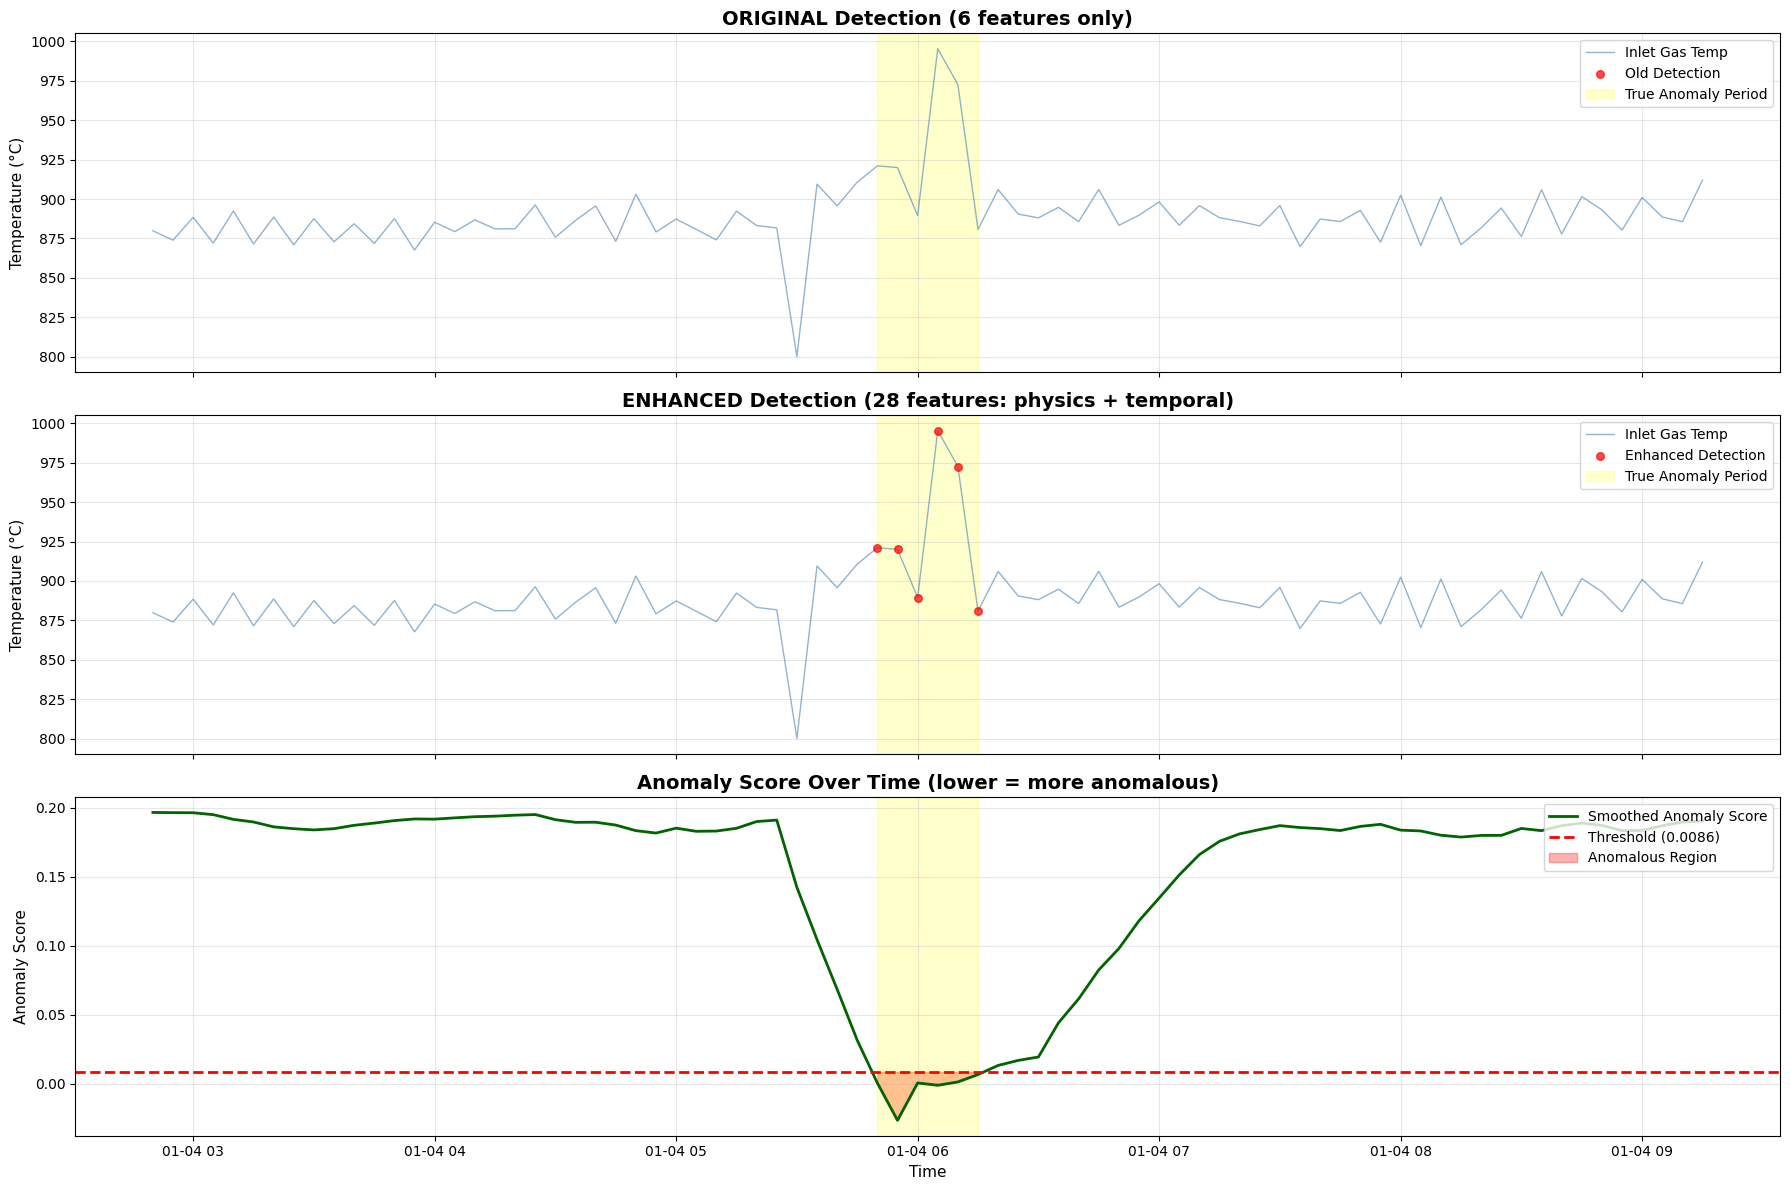

✅ Saved: physics_features_during_anomaly.png


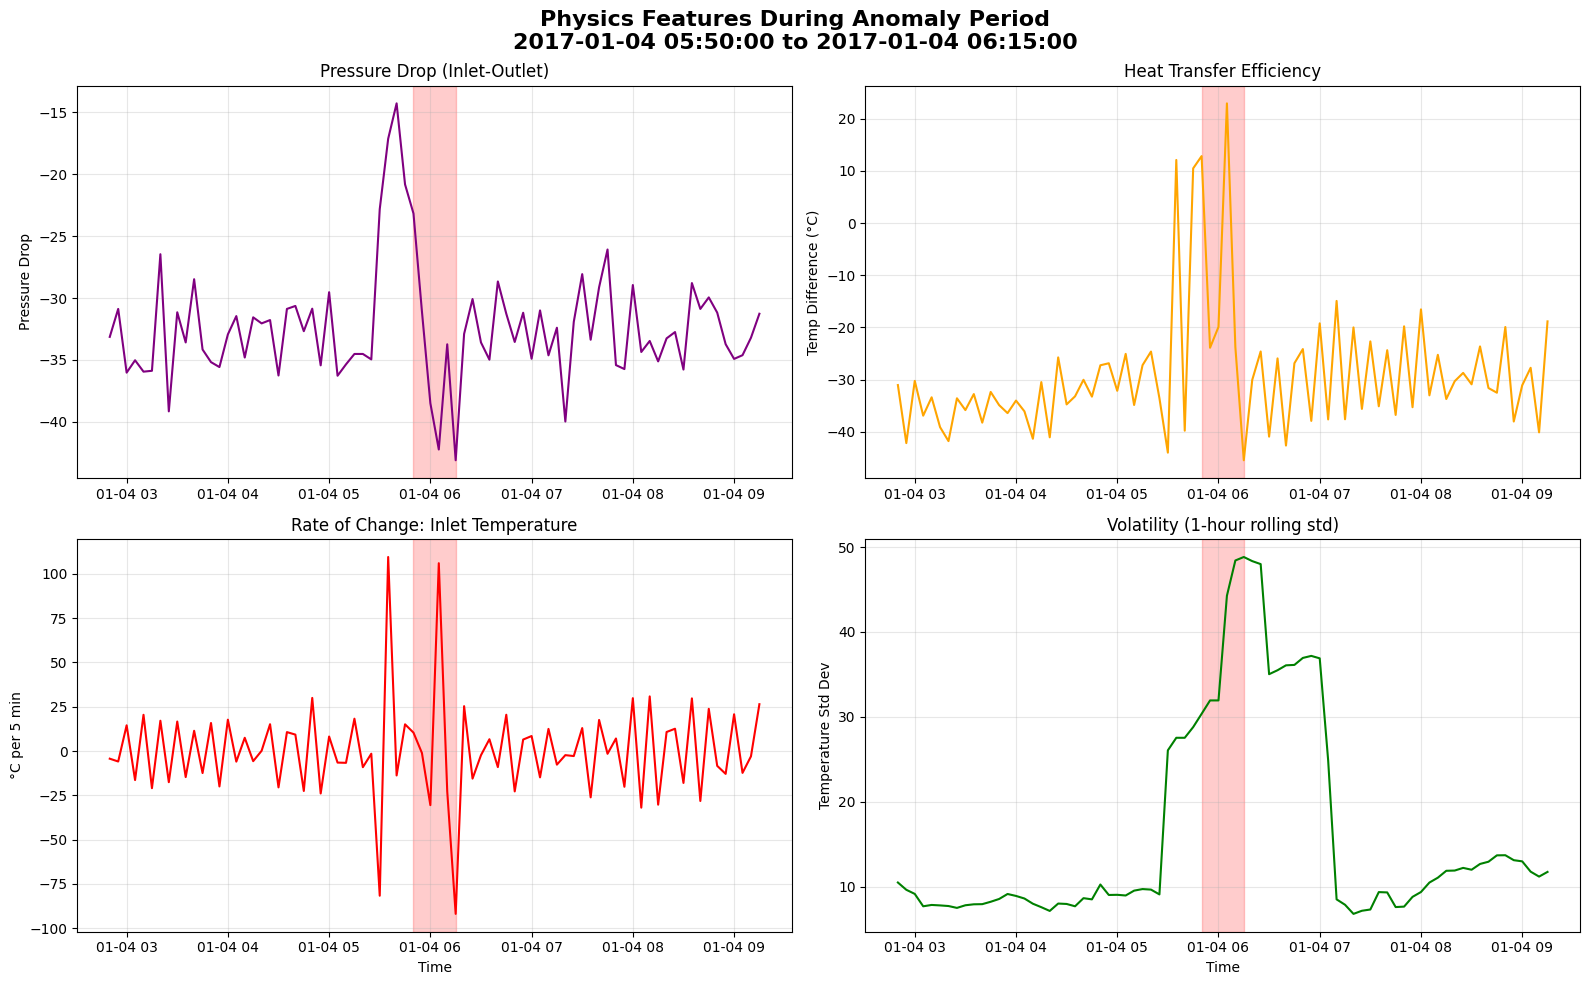


✅ Visualization complete!


In [ ]:
# ============================================
# VISUALIZATION: Compare Old vs New
# ============================================

print("\n📈 Creating comparison visualizations...\n")

# Select an interesting time window that has anomalies
# Let's use the longest anomaly period from the results
if periods_df is not None and len(periods_df) > 0:
    # Get the longest period
    longest = periods_df.iloc[0]

    # Expand window to show context (3 hours before and after)
    viz_start = longest['start_time'] - pd.Timedelta(hours=3)
    viz_end = longest['end_time'] + pd.Timedelta(hours=3)

    print(f"Visualizing period: {longest['start_time']} to {longest['end_time']}")
    print(f"Duration: {longest['duration']}")
    print(f"Extended window for context: {viz_start} to {viz_end}\n")

    # Filter data for this window
    mask_new = (df1_clean['time'] >= viz_start) & (df1_clean['time'] <= viz_end)
    window_new = df1_clean[mask_new].copy()

    # Try to get old results for same window
    if 'df_clean' in locals():
        mask_old = (df_clean['time'] >= viz_start) & (df_clean['time'] <= viz_end)
        window_old = df_clean[mask_old].copy()
    else:
        window_old = None

    # ============================================
    # PLOT 1: Temperature with Both Detections
    # ============================================

    fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

    # Subplot 1: Original Detection
    axes[0].plot(window_new['time'], window_new['Cyclone_Inlet_Gas_Temp'],
                 color='steelblue', alpha=0.6, linewidth=1, label='Inlet Gas Temp')

    if window_old is not None:
        old_anoms = window_old[window_old['is_anomaly'] == 1]
        axes[0].scatter(old_anoms['time'], old_anoms['Cyclone_Inlet_Gas_Temp'],
                       color='red', s=30, alpha=0.7, label='Old Detection', zorder=5)

    axes[0].axvspan(longest['start_time'], longest['end_time'],
                    color='yellow', alpha=0.2, label='True Anomaly Period')
    axes[0].set_title('ORIGINAL Detection (6 features only)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Temperature (°C)', fontsize=11)
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)

    # Subplot 2: Enhanced Detection
    axes[1].plot(window_new['time'], window_new['Cyclone_Inlet_Gas_Temp'],
                 color='steelblue', alpha=0.6, linewidth=1, label='Inlet Gas Temp')

    new_anoms = window_new[window_new['is_anomaly_smoothed'] == 1]
    axes[1].scatter(new_anoms['time'], new_anoms['Cyclone_Inlet_Gas_Temp'],
                   color='red', s=30, alpha=0.7, label='Enhanced Detection', zorder=5)

    axes[1].axvspan(longest['start_time'], longest['end_time'],
                    color='yellow', alpha=0.2, label='True Anomaly Period')
    axes[1].set_title('ENHANCED Detection (28 features: physics + temporal)',
                      fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Temperature (°C)', fontsize=11)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    # Subplot 3: Anomaly Scores Comparison
    axes[2].plot(window_new['time'], window_new['anomaly_score_smoothed'],
                 color='darkgreen', linewidth=2, label='Smoothed Anomaly Score')
    axes[2].axhline(y=threshold, color='red', linestyle='--',
                    linewidth=2, label=f'Threshold ({threshold:.4f})')
    axes[2].fill_between(window_new['time'], threshold,
                         window_new['anomaly_score_smoothed'],
                         where=(window_new['anomaly_score_smoothed'] < threshold),
                         color='red', alpha=0.3, label='Anomalous Region')
    axes[2].axvspan(longest['start_time'], longest['end_time'],
                    color='yellow', alpha=0.2)
    axes[2].set_title('Anomaly Score Over Time (lower = more anomalous)',
                      fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Time', fontsize=11)
    axes[2].set_ylabel('Anomaly Score', fontsize=11)
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('enhanced_vs_original_detection.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: enhanced_vs_original_detection.png")
    plt.show()

    # ============================================
    # PLOT 2: Physics Features During Anomaly
    # ============================================

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Physics Features During Anomaly Period\n{longest["start_time"]} to {longest["end_time"]}',
                 fontsize=16, fontweight='bold')

    # Pressure Drop
    axes[0, 0].plot(window_new['time'], window_new['Pressure_Drop_Inlet_Outlet'],
                    color='purple', linewidth=1.5)
    axes[0, 0].axvspan(longest['start_time'], longest['end_time'],
                       color='red', alpha=0.2)
    axes[0, 0].set_title('Pressure Drop (Inlet-Outlet)')
    axes[0, 0].set_ylabel('Pressure Drop')
    axes[0, 0].grid(True, alpha=0.3)

    # Heat Transfer Efficiency
    axes[0, 1].plot(window_new['time'], window_new['Heat_Transfer_Efficiency'],
                    color='orange', linewidth=1.5)
    axes[0, 1].axvspan(longest['start_time'], longest['end_time'],
                       color='red', alpha=0.2)
    axes[0, 1].set_title('Heat Transfer Efficiency')
    axes[0, 1].set_ylabel('Temp Difference (°C)')
    axes[0, 1].grid(True, alpha=0.3)

    # Rate of Change (Inlet Temp)
    axes[1, 0].plot(window_new['time'], window_new['Cyclone_Inlet_Gas_Temp_RateOfChange'],
                    color='red', linewidth=1.5)
    axes[1, 0].axvspan(longest['start_time'], longest['end_time'],
                       color='red', alpha=0.2)
    axes[1, 0].set_title('Rate of Change: Inlet Temperature')
    axes[1, 0].set_ylabel('°C per 5 min')
    axes[1, 0].set_xlabel('Time')
    axes[1, 0].grid(True, alpha=0.3)

    # Volatility
    axes[1, 1].plot(window_new['time'], window_new['Cyclone_Inlet_Gas_Temp_Volatility_1h'],
                    color='green', linewidth=1.5)
    axes[1, 1].axvspan(longest['start_time'], longest['end_time'],
                       color='red', alpha=0.2)
    axes[1, 1].set_title('Volatility (1-hour rolling std)')
    axes[1, 1].set_ylabel('Temperature Std Dev')
    axes[1, 1].set_xlabel('Time')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('physics_features_during_anomaly.png', dpi=300, bbox_inches='tight')
    print("✅ Saved: physics_features_during_anomaly.png")
    plt.show()

print("\n✅ Visualization complete!")

In [ ]:
# ============================================
# BONUS: ROOT CAUSE ANALYSIS
# ============================================

print("\n🕵️‍♂️ PERFORMING ROOT CAUSE ANALYSIS ON TOP 5 EVENTS...")
print("-" * 60)

# Get the top 5 longest periods
top_periods = periods_df.nlargest(5, 'duration')

# We will compare the values during the anomaly to the 'Normal' mean
# (Normal = when is_anomaly == 0)
normal_data = df1_clean[df1_clean['is_anomaly'] == 0]
feature_means = normal_data[feature_cols].mean()
feature_stds = normal_data[feature_cols].std()

for idx, row in top_periods.iterrows():
    start = row['start_time']
    end = row['end_time']

    # Get data for this specific anomaly period
    period_data = df1_clean[(df1_clean['time'] >= start) & (df1_clean['time'] <= end)]

    print(f"\nPeriod: {start} to {end} (Duration: {row['duration']})")

    # Calculate Z-scores for this period (How far is each feature from normal?)
    # We take the mean of the period and compare it to global normal stats
    period_mean = period_data[feature_cols].mean()
    z_scores = ((period_mean - feature_means) / feature_stds).abs()

    # Find top 3 contributing features
    top_drivers = z_scores.nlargest(3)

    for feature, z_score in top_drivers.items():
        val = period_mean[feature]
        normal_val = feature_means[feature]
        print(f"  > Driver: {feature:<35} | Deviation: {z_score:.2f}x std dev | Value: {val:.2f} (Normal: {normal_val:.2f})")

print("\n" + "="*60)


🕵️‍♂️ PERFORMING ROOT CAUSE ANALYSIS ON TOP 5 EVENTS...
------------------------------------------------------------

Period: 2018-07-13 19:55:00 to 2018-07-14 02:40:00 (Duration: 0 days 06:45:00)
  > Driver: Cyclone_Outlet_Gas_draft_Volatility_1h | Deviation: 5.32x std dev | Value: 28.36 (Normal: 5.11)
  > Driver: Cyclone_Gas_Outlet_Temp_Volatility_1h | Deviation: 5.18x std dev | Value: 61.32 (Normal: 9.84)
  > Driver: Cyclone_Inlet_Draft_Volatility_1h   | Deviation: 4.50x std dev | Value: 22.07 (Normal: 4.74)

Period: 2018-07-10 12:45:00 to 2018-07-10 17:05:00 (Duration: 0 days 04:20:00)
  > Driver: Cyclone_Inlet_Draft_Volatility_1h   | Deviation: 4.83x std dev | Value: 23.31 (Normal: 4.74)
  > Driver: Cyclone_Gas_Outlet_Temp_Volatility_1h | Deviation: 4.69x std dev | Value: 56.48 (Normal: 9.84)
  > Driver: Cyclone_Outlet_Gas_draft_Volatility_1h | Deviation: 4.33x std dev | Value: 24.02 (Normal: 5.11)

Period: 2019-10-26 12:10:00 to 2019-10-26 16:30:00 (Duration: 0 days 04:20:00)
  

🎨 Generating Advanced Visualizations Suite...
✅ Generated: Viz1_Physics_Phase_Space.png


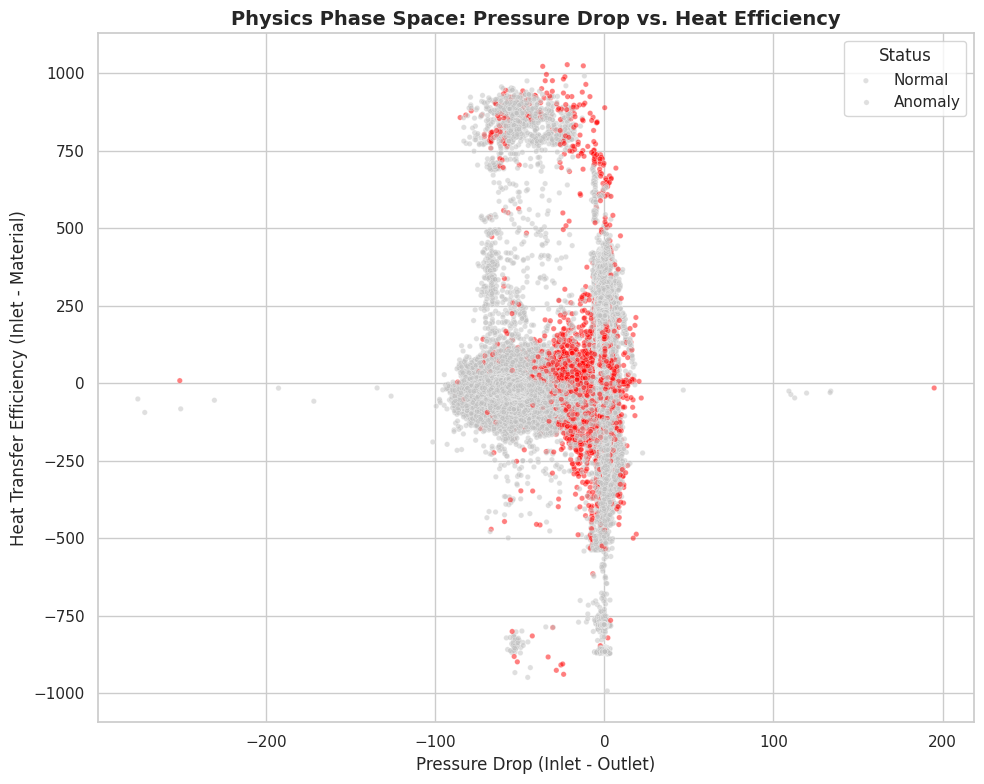

✅ Generated: Viz2_Feature_Boxplots.png


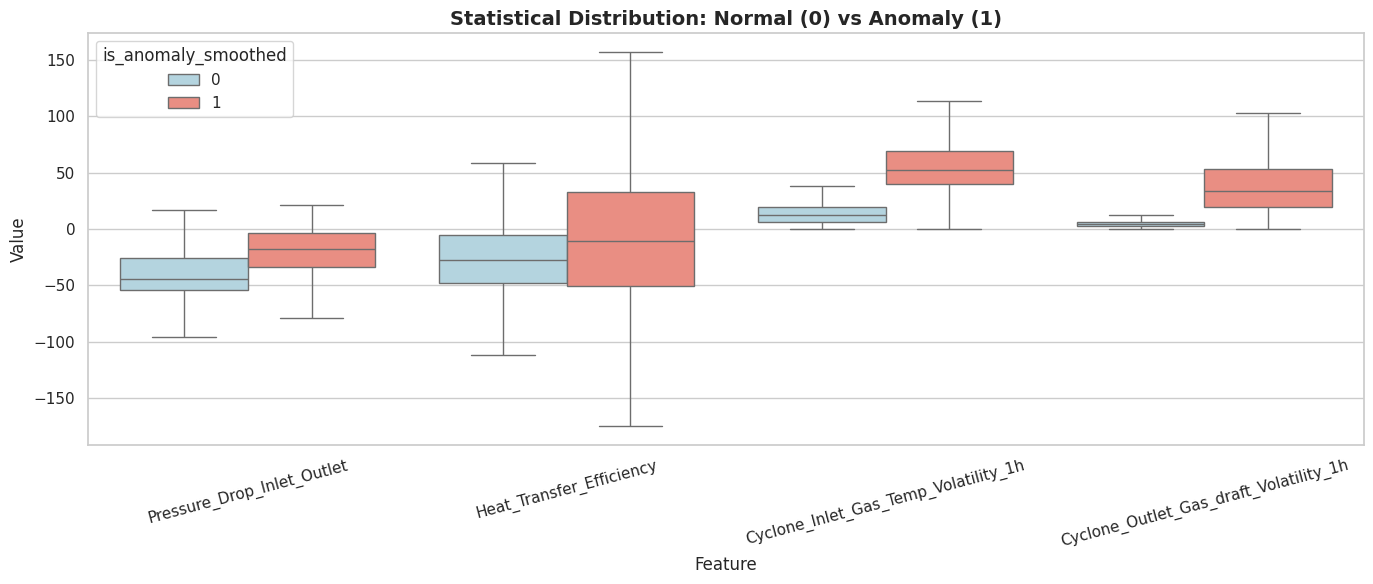

✅ Generated: Viz3_Anomaly_Gantt.png


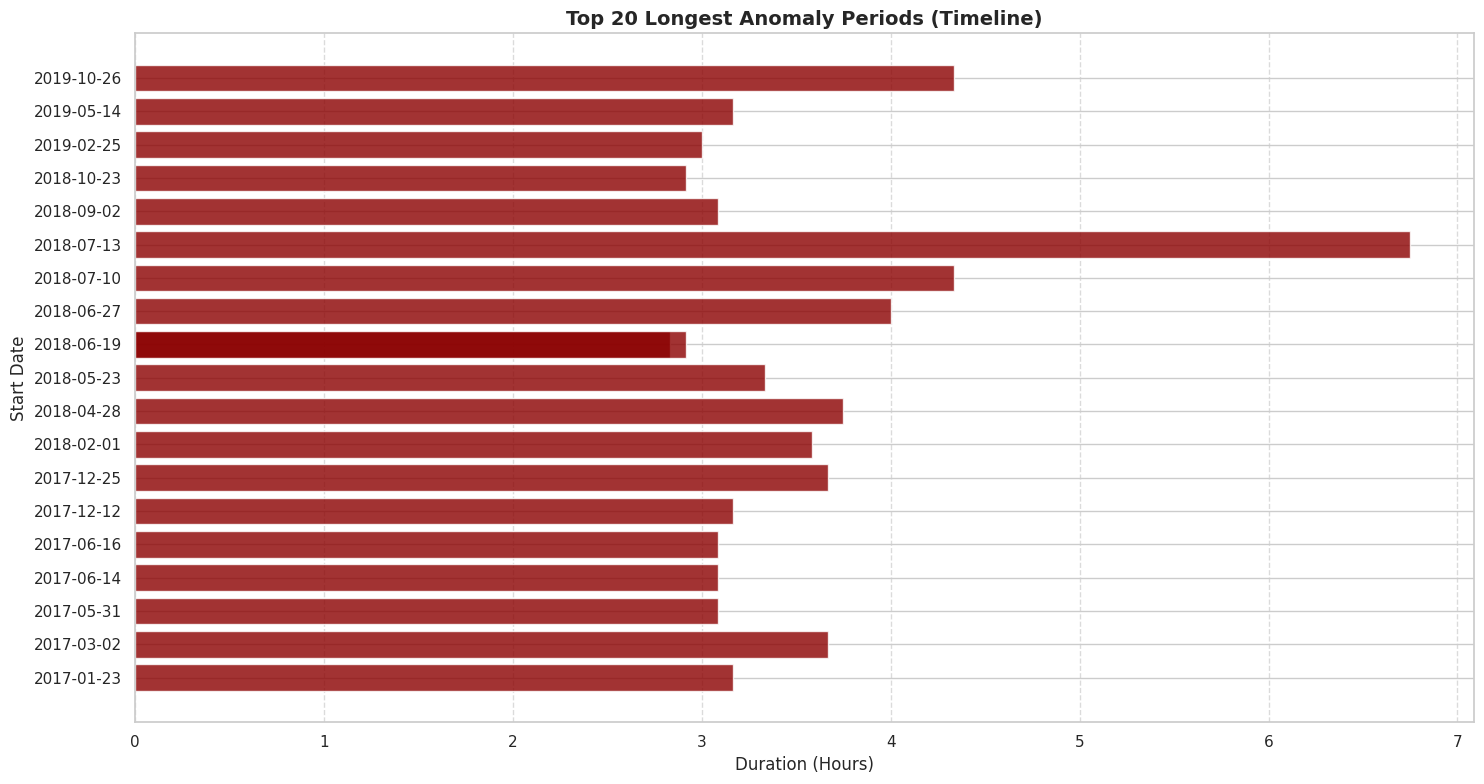

✅ Generated: Viz4_Temporal_Heatmap.png


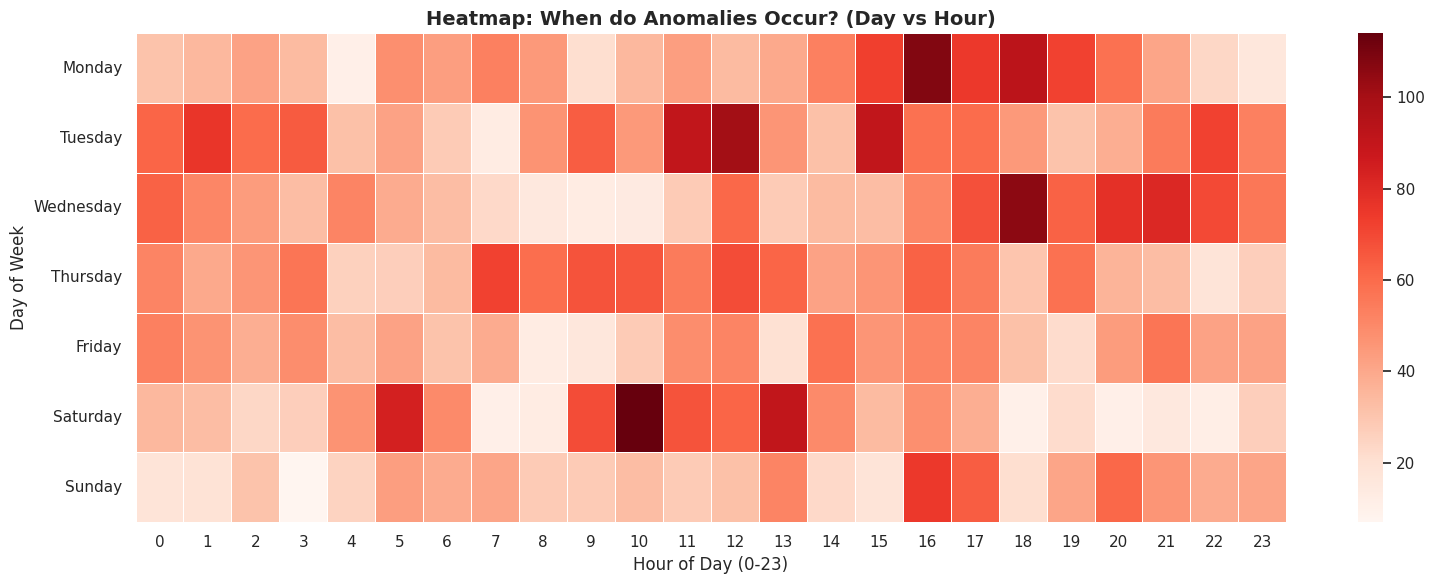

✅ Generated: Viz5_Correlation_Breakdown.png


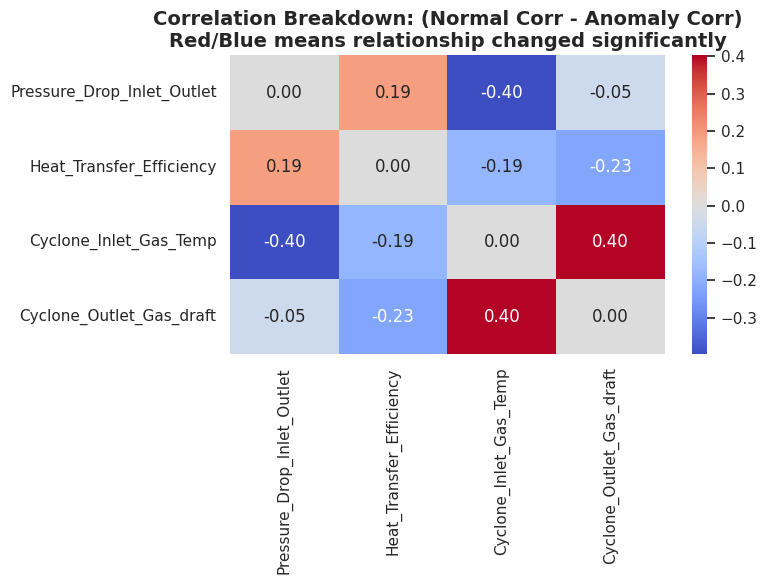


🎉 All Visualizations Generated Successfully!


In [ ]:
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

# Set the style for professional plotting
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

print("🎨 Generating Advanced Visualizations Suite...")

# ========================================================
# GRAPH 1: The "Phase Space" Plot (Physics Relationship)
# ========================================================
# This shows how the machine operates in 2D physics space.
# Normal operation is a tight cluster. Anomalies drift away.

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df1_clean,
    x='Pressure_Drop_Inlet_Outlet',
    y='Heat_Transfer_Efficiency',
    hue='is_anomaly_smoothed',
    palette={0: 'silver', 1: 'red'},
    alpha=0.5,
    s=15
)
plt.title('Physics Phase Space: Pressure Drop vs. Heat Efficiency', fontsize=14, fontweight='bold')
plt.xlabel('Pressure Drop (Inlet - Outlet)', fontsize=12)
plt.ylabel('Heat Transfer Efficiency (Inlet - Material)', fontsize=12)
plt.legend(title='Status', labels=['Normal', 'Anomaly'])
plt.tight_layout()
plt.savefig('Viz1_Physics_Phase_Space.png', dpi=300)
print("✅ Generated: Viz1_Physics_Phase_Space.png")
plt.show()

# ========================================================
# GRAPH 2: Box Plots of Key Drivers (Statistical Separation)
# ========================================================
# This proves that the anomalies are statistically different from normal data.

# Select key features to compare
cols_to_compare = [
    'Pressure_Drop_Inlet_Outlet',
    'Heat_Transfer_Efficiency',
    'Cyclone_Inlet_Gas_Temp_Volatility_1h',
    'Cyclone_Outlet_Gas_draft_Volatility_1h'
]

# Melt data for plotting
df_melted = df1_clean.melt(
    id_vars=['is_anomaly_smoothed'],
    value_vars=cols_to_compare,
    var_name='Feature',
    value_name='Value'
)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_melted,
    x='Feature',
    y='Value',
    hue='is_anomaly_smoothed',
    palette={0: 'lightblue', 1: 'salmon'},
    showfliers=False # Hide extreme outliers to see the box better
)
plt.title('Statistical Distribution: Normal (0) vs Anomaly (1)', fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('Viz2_Feature_Boxplots.png', dpi=300)
print("✅ Generated: Viz2_Feature_Boxplots.png")
plt.show()

# ========================================================
# GRAPH 3: Anomaly Timeline (Gantt Chart)
# ========================================================
# This shows the Duration and Frequency of anomalies over the 3 years.

if periods_df is not None and not periods_df.empty:
    # Get top 20 longest anomalies for cleaner plot
    top_periods_viz = periods_df.nlargest(20, 'duration').sort_values('start_time')

    plt.figure(figsize=(15, 8))

    # Convert duration to hours for bar length
    dur_hours = top_periods_viz['duration'].dt.total_seconds() / 3600

    plt.barh(
        y=top_periods_viz['start_time'].dt.strftime('%Y-%m-%d'),
        width=dur_hours,
        color='darkred',
        alpha=0.8
    )

    plt.title('Top 20 Longest Anomaly Periods (Timeline)', fontsize=14, fontweight='bold')
    plt.xlabel('Duration (Hours)', fontsize=12)
    plt.ylabel('Start Date', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Viz3_Anomaly_Gantt.png', dpi=300)
    print("✅ Generated: Viz3_Anomaly_Gantt.png")
    plt.show()

# ========================================================
# GRAPH 4: Heatmap of Temporal Patterns
# ========================================================
# Do anomalies happen at specific times of day? (e.g., Shift Changes?)

# Extract hour from anomaly rows
anom_rows = df1_clean[df1_clean['is_anomaly_smoothed'] == 1].copy()
anom_rows['hour'] = anom_rows['time'].dt.hour
anom_rows['day_of_week'] = anom_rows['time'].dt.day_name()

# Order for days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Create pivot table for heatmap
heatmap_data = anom_rows.pivot_table(
    index='day_of_week',
    columns='hour',
    values='is_anomaly_smoothed',
    aggfunc='count',
    fill_value=0
).reindex(days_order)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='Reds', linewidths=0.5, linecolor='white')
plt.title('Heatmap: When do Anomalies Occur? (Day vs Hour)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.savefig('Viz4_Temporal_Heatmap.png', dpi=300)
print("✅ Generated: Viz4_Temporal_Heatmap.png")
plt.show()

# ========================================================
# GRAPH 5: Correlation Difference (Normal vs Anomaly)
# ========================================================
# Shows how physics relationships BREAK during anomalies.

# Calculate correlations for normal and anomalous data
corr_normal = df1_clean[df1_clean['is_anomaly_smoothed'] == 0][['Pressure_Drop_Inlet_Outlet', 'Heat_Transfer_Efficiency', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Outlet_Gas_draft']].corr()
corr_anom = df1_clean[df1_clean['is_anomaly_smoothed'] == 1][['Pressure_Drop_Inlet_Outlet', 'Heat_Transfer_Efficiency', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Outlet_Gas_draft']].corr()

# Calculate the DIFFERENCE
corr_diff = corr_normal - corr_anom

plt.figure(figsize=(8, 6))
sns.heatmap(corr_diff, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Breakdown: (Normal Corr - Anomaly Corr)\nRed/Blue means relationship changed significantly', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Viz5_Correlation_Breakdown.png', dpi=300)
print("✅ Generated: Viz5_Correlation_Breakdown.png")
plt.show()

print("\n🎉 All Visualizations Generated Successfully!")

# **END**

In [ ]:
# Clean data by replacing error strings with NaN
df_clean[sensor_cols] = df_clean[sensor_cols].replace(error_keywords, np.nan)


In [ ]:
error_values_exist=df_clean['Cyclone_Gas_Outlet_Temp'].isin(['unit down']).any()
print (f" 'Cyclone_Gas_Outlet_Temp' contain '{'unit down'}'? {error_values_exist}") # this gives false if all error values have been replaced with nan values.

 'Cyclone_Gas_Outlet_Temp' contain 'unit down'? False


In [ ]:
# Now I will  Convrt  all cols. except time col. to numeric
for col in sensor_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")



In [ ]:
df_clean.dtypes  # checkng data-typs

,0
time,object
Cyclone_Inlet_Gas_Temp,float64
Cyclone_Material_Temp,float64
Cyclone_Outlet_Gas_draft,float64
Cyclone_cone_draft,float64
Cyclone_Gas_Outlet_Temp,float64
Cyclone_Inlet_Draft,float64


In [ ]:
#  Now time format  Convertd  to datetime
df_clean["time"] = pd.to_datetime(df_clean["time"], errors="coerce")


In [ ]:
df_clean['time'].dtypes  # checkng data-time format

dtype('<M8[ns]')

In [ ]:
# Now since NaN values are not needed so I will drop rows whre ANY sensor_cols or time is NaN
df_clean = df_clean.dropna(subset=["time"] + sensor_cols)

print(" Shape after cleaning is :", df_clean.shape)
df_clean.head()

 Shape after cleaning is : (376124, 7)


,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
0,2017-01-01 00:00:00,867.63,910.42,-189.54,-186.04,852.13,-145.90
1,2017-01-01 00:05:00,879.23,918.14,-184.33,-182.10,862.53,-149.76
2,2017-01-01 00:10:00,875.67,924.18,-181.26,-166.47,866.06,-145.01
3,2017-01-01 00:15:00,875.28,923.15,-179.15,-174.83,865.85,-142.82
4,2017-01-01 00:20:00,891.66,934.26,-178.32,-173.72,876.06,-143.39


In [ ]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 376124 entries, 0 to 377718
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   time                      376124 non-null  datetime64[ns]
 1   Cyclone_Inlet_Gas_Temp    376124 non-null  float64       
 2   Cyclone_Material_Temp     376124 non-null  float64       
 3   Cyclone_Outlet_Gas_draft  376124 non-null  float64       
 4   Cyclone_cone_draft        376124 non-null  float64       
 5   Cyclone_Gas_Outlet_Temp   376124 non-null  float64       
 6   Cyclone_Inlet_Draft       376124 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 23.0 MB
None


In [ ]:
#  Sorting by time
df_clean = df_clean.sort_values("time")

print(df_clean.describe())


                                time  Cyclone_Inlet_Gas_Temp  \
count                         376124           376124.000000   
mean   2018-10-21 01:56:22.020557568              727.387946   
min              2017-01-01 00:00:00                0.000000   
25%              2017-11-27 05:03:45              856.280000   
50%              2018-10-21 08:57:30              882.380000   
75%              2019-09-14 12:41:15              901.120000   
max              2020-08-07 12:15:00             1157.630000   
std                              NaN              328.634044   

       Cyclone_Material_Temp  Cyclone_Outlet_Gas_draft  Cyclone_cone_draft  \
count          376124.000000             376124.000000       376124.000000   
mean              750.828429               -177.830733         -164.582678   
min              -185.000000               -456.660000         -459.310000   
25%               867.660000               -247.190000         -226.770000   
50%               913.360000     

now doing Feature scaling for making standarsized data

In [ ]:
df_clean.head()

,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
0,2017-01-01 00:00:00,867.63,910.42,-189.54,-186.04,852.13,-145.90
1,2017-01-01 00:05:00,879.23,918.14,-184.33,-182.10,862.53,-149.76
2,2017-01-01 00:10:00,875.67,924.18,-181.26,-166.47,866.06,-145.01
3,2017-01-01 00:15:00,875.28,923.15,-179.15,-174.83,865.85,-142.82
4,2017-01-01 00:20:00,891.66,934.26,-178.32,-173.72,876.06,-143.39


 using standardscaler for standardize the data, so it will be helpful for my isolation forest model buildng as it works better when all featurs r on similr scales

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Extrct feature matrix X
X = df_clean[sensor_cols].values  # keep order of sensor_cols

# 2. Standrdize features (mean 0, std 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X.shape)
print("X_scaled shape:", X_scaled.shape)


X shape: (376124, 6)
X_scaled shape: (376124, 6)


importng & training on Isolation Forest algo...
Analysis Strategy:
->Since we need to hilight time periods of abnormality,
->im gonna use Isolation Forest algorithm.
->its good for finding wierdos in the data without labels.


In [ ]:
from sklearn.ensemble import IsolationForest

# 1. Initialize model
iso = IsolationForest(
    n_estimators=200,      # number of trees
    contamination=0.01,   # expected proportion of anomalies (1% to start)
    random_state=42,
    n_jobs=1              # use 1 core to be safe; you can increase if your laptop is strong
)

# 2. Fit the model on scaled data
iso.fit(X_scaled)

# 3. Get anomaly scores and labels
scores = iso.decision_function(X_scaled)  # higher = more normal
labels = iso.predict(X_scaled)           # 1 = normal, -1 = anomaly

# 4. Attach back to df_clean
df_clean["anomaly_score"] = -scores            # invert so higher = more anomalous
df_clean["is_anomaly"] = (labels == -1).astype(int)  # 1 for anomaly, 0 for normal

# 5. Check how many anomalies
print("Anomaly fraction:", df_clean["is_anomaly"].mean())
df_clean.head()


Anomaly fraction: 0.010002020610224288


,time,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft,anomaly_score,is_anomaly
0,2017-01-01 00:00:00,867.63,910.42,-189.54,-186.04,852.13,-145.90,-0.282497,0
1,2017-01-01 00:05:00,879.23,918.14,-184.33,-182.10,862.53,-149.76,-0.284485,0
2,2017-01-01 00:10:00,875.67,924.18,-181.26,-166.47,866.06,-145.01,-0.267715,0
3,2017-01-01 00:15:00,875.28,923.15,-179.15,-174.83,865.85,-142.82,-0.263702,0
4,2017-01-01 00:20:00,891.66,934.26,-178.32,-173.72,876.06,-143.39,-0.259905,0


In [ ]:
# index sorted by time and using time as index so that it gives result for every 5 min intervl
df_time = df_clean.sort_values("time").set_index("time")

# Filter anomalies
anoms = df_time[df_time["is_anomaly"] == 1].copy()
anoms = anoms.sort_index()


In [ ]:
print("Number of anomalous points:", len(anoms))  # anamoly no.

Number of anomalous points: 3762


In [ ]:
# Time differnce b/w consecutive anamoly timestamps
anoms["time_diff"] = anoms.index.to_series().diff()

# Base sampling step (should be ~5 minutes)
full_time_diff = df_time.index.to_series().diff().dropna()
expected_step = full_time_diff.mode()[0]
print("Expected base time step:", expected_step)

Expected base time step: 0 days 00:05:00


In [ ]:
# Gap threshold: separate periods if anomalies are far apart
gap_threshold = 3 * expected_step

#  I Start a new period when first anomaly OR gap is too large
anoms["new_period"] = (anoms["time_diff"].isna()) | (anoms["time_diff"] > gap_threshold)
anoms["period_id"] = anoms["new_period"].cumsum()


In [ ]:
# Build periods table with REAL times
period_list = []
for pid, group in anoms.groupby("period_id"):
    start_time = group.index.min()
    end_time   = group.index.max()
    duration   = end_time - start_time
    n_points   = len(group)
    max_score  = group["anomaly_score"].max()
    avg_score  = group["anomaly_score"].mean()

    period_list.append({
        "period_id": pid,
        "start_time": start_time,
        "end_time": end_time,
        "duration": duration,
        "n_points": n_points,
        "max_anomaly_score": max_score,
        "avg_anomaly_score": avg_score
    })

periods = pd.DataFrame(period_list)
periods.head()

,period_id,start_time,end_time,duration,n_points,max_anomaly_score,avg_anomaly_score
0,1,2017-01-23 02:15:00,2017-01-23 02:15:00,0 days 00:00:00,1,0.010693,0.010693
1,2,2017-01-23 05:15:00,2017-01-23 05:15:00,0 days 00:00:00,1,0.002080,0.002080
2,3,2017-01-23 06:00:00,2017-01-23 06:55:00,0 days 00:55:00,10,0.025838,0.007857
3,4,2017-01-23 13:15:00,2017-01-23 13:15:00,0 days 00:00:00,1,0.012521,0.012521
4,5,2017-01-23 14:15:00,2017-01-23 14:50:00,0 days 00:35:00,6,0.018766,0.007289


In [ ]:
# Save periods table
periods.to_csv("abnormal_periods.csv", index=False)

# Optionally save the full dataframe with anomaly flags
df_clean.to_csv("data_with_anomalies.csv")


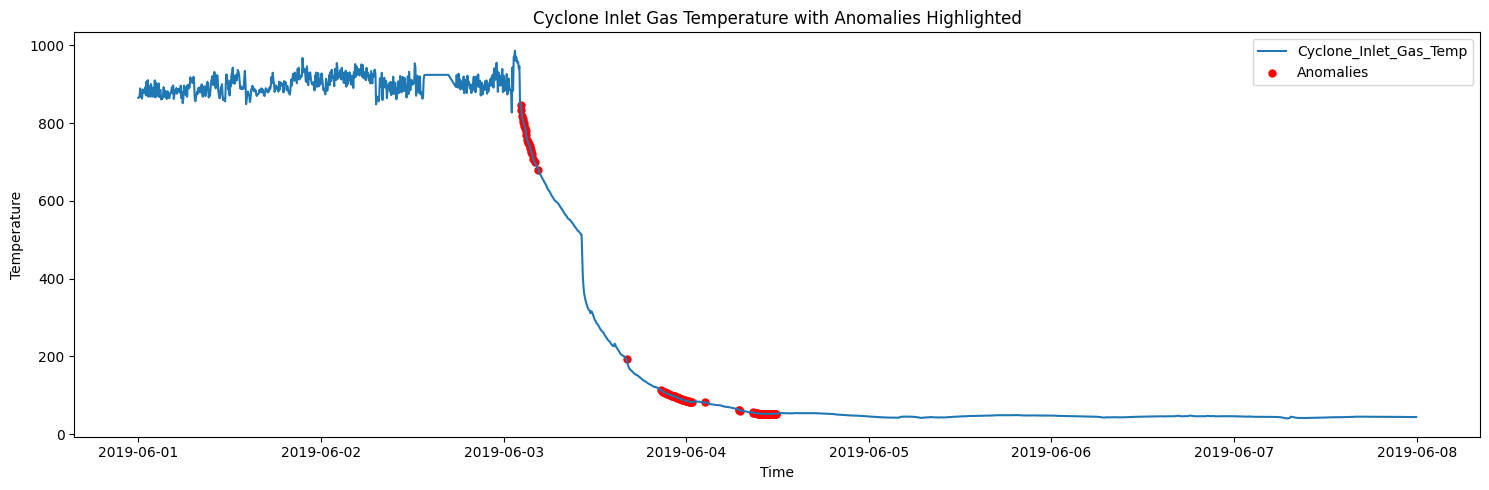

In [ ]:
import matplotlib.pyplot as plt

df_plot = df_clean.sort_values("time").copy()   # sorting I already have done i guess but repeating so that no error occur
df_plot = df_plot.set_index("time")

#  choos a smll time window to visualize
start = "2019-06-01"
end = "2019-06-07"
window = df_plot.loc[start:end]

#  separating  bad result  in this window
anoms_window = window[window["is_anomaly"] == 1]

#  Plt
plt.figure(figsize=(15, 5))

plt.plot(window.index,
         window["Cyclone_Inlet_Gas_Temp"],
         label="Cyclone_Inlet_Gas_Temp")

#  making bad  points in red
plt.scatter(anoms_window.index,
            anoms_window["Cyclone_Inlet_Gas_Temp"],
            color="red",
            s=25,
            label="Anomalies")

plt.title("Cyclone Inlet Gas Temperature with Anomalies Highlighted")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.tight_layout()
plt.show()


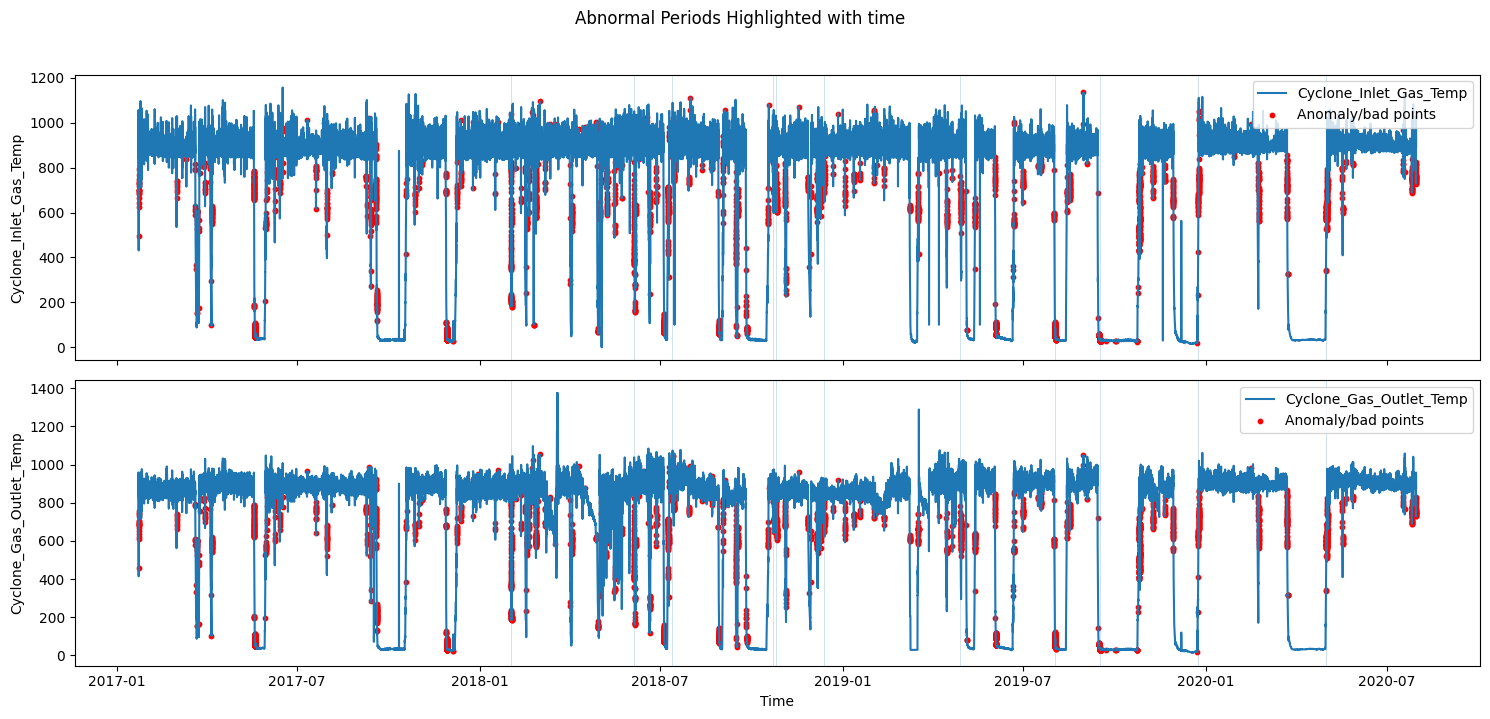

In [ ]:

import matplotlib.pyplot as plt # done already above , but for this seprately

# Choose only 2  to plot to get overall idea accord to 2
features_to_plot = [
    "Cyclone_Inlet_Gas_Temp",
    "Cyclone_Gas_Outlet_Temp"
]

# restricting  the plot to a smaller time range that has anomalies
start = periods["start_time"].min() - pd.Timedelta(hours=3)
end   = periods["end_time"].max()   + pd.Timedelta(hours=3)

df_plot_window = df_plot.loc[start:end]

# Creating  subplots
fig, axes = plt.subplots(len(features_to_plot), 1, figsize=(15, 7), sharex=True)

if len(features_to_plot) == 1:
    axes = [axes]  # make it iterable

for i, col in enumerate(features_to_plot):
    ax = axes[i]

    # Plot full signl
    ax.plot(df_plot_window.index, df_plot_window[col], label=col)

    # make bad points in red
    anoms_col = df_plot_window[df_plot_window["is_anomaly"] == 1]
    ax.scatter(anoms_col.index,
               anoms_col[col],
               color="red",
               s=10,
               label="Anomaly/bad points")

    # Shade bad  periods
    for _, row in periods.iterrows():
        # Only shade if the period overlaps with our window
        if (row["end_time"] >= df_plot_window.index.min()) and (row["start_time"] <= df_plot_window.index.max()):
            ax.axvspan(row["start_time"], row["end_time"], alpha=0.2)

    ax.set_ylabel(col)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time")
fig.suptitle("Abnormal Periods Highlighted with time  ", y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipython-input-4180697899.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies['group_id'] = (anomalies['time'].diff() > pd.Timedelta(minutes=15)).cumsum()


Abnormal Periods Detected:
Period 0: From 2017-01-04 05:50:00 to 2017-01-04 06:15:00 | Duration: 0 days 00:25:00
Period 1: From 2017-01-07 00:10:00 to 2017-01-07 00:15:00 | Duration: 0 days 00:05:00
Period 2: From 2017-01-08 05:30:00 to 2017-01-08 05:40:00 | Duration: 0 days 00:10:00
Period 3: From 2017-01-19 09:10:00 to 2017-01-19 10:20:00 | Duration: 0 days 01:10:00
Period 4: From 2017-01-20 05:00:00 to 2017-01-20 05:20:00 | Duration: 0 days 00:20:00
Period 5: From 2017-01-22 23:35:00 to 2017-01-23 00:40:00 | Duration: 0 days 01:05:00
Period 6: From 2017-01-23 01:10:00 to 2017-01-23 03:45:00 | Duration: 0 days 02:35:00
Period 7: From 2017-01-23 05:25:00 to 2017-01-23 08:40:00 | Duration: 0 days 03:15:00
Period 8: From 2017-01-23 13:20:00 to 2017-01-23 14:15:00 | Duration: 0 days 00:55:00
Period 9: From 2017-01-23 14:55:00 to 2017-01-23 16:00:00 | Duration: 0 days 01:05:00
Period 10: From 2017-01-25 16:35:00 to 2017-01-25 18:45:00 | Duration: 0 days 02:10:00
Period 11: From 2017-01-26

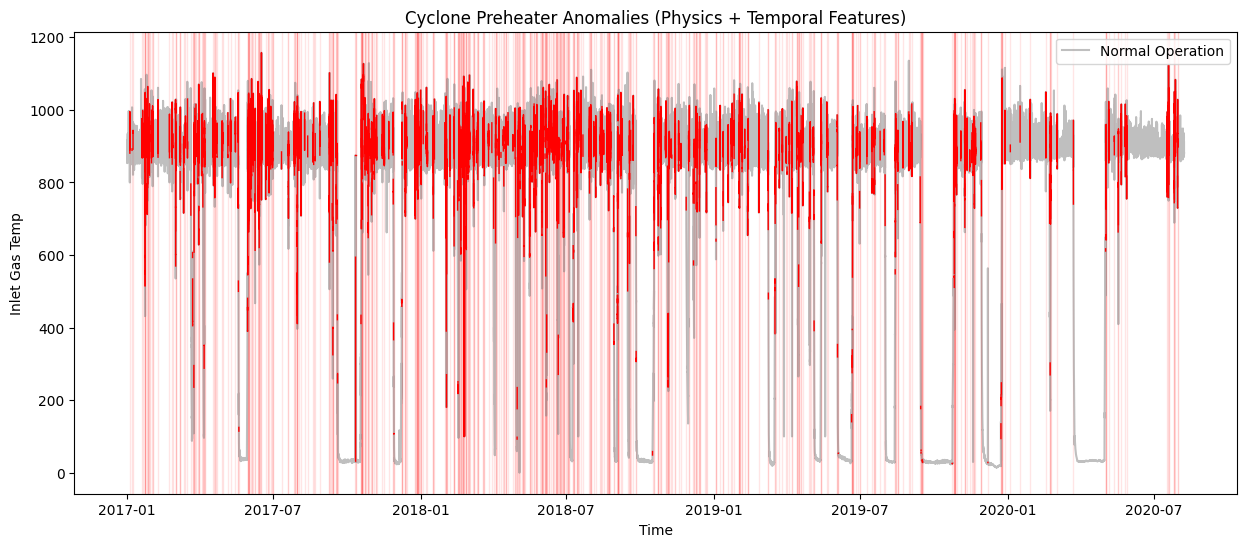

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest

# ==========================================
# 1. DATA LOADING & ROBUST CLEANING
# ==========================================
def load_and_clean_data(filepath):
    df = pd.read_csv(filepath)

    # Define sensor columns (exclude time)
    sensor_cols = [
        'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp',
        'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft',
        'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft'
    ]

    # Standardize column names if needed (strip spaces)
    df.columns = df.columns.str.strip()

    # Convert Time
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df = df.sort_values('time').reset_index(drop=True)

    # Handle Error Strings ("Not Connect", "Unit Down", etc.)
    # Instead of just dropping, we turn them to NaN first
    error_keywords = ["not connect", "unit down", "timeout", "bad", "comm fail", "configure"]
    for col in sensor_cols:
        # Force numeric, turning errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # INTELLIGENT FILLING: Linear Interpolation
    # This preserves the trend instead of deleting time periods
    df[sensor_cols] = df[sensor_cols].interpolate(method='linear', limit_direction='both')

    # Drop any remaining NaNs (timestamps that failed)
    df = df.dropna()

    return df, sensor_cols

# ==========================================
# 2. PHYSICS-INFORMED FEATURE ENGINEERING
# ==========================================
def create_features(df, sensor_cols):
    data = df.copy()

    # --- A. Physics Features ---
    # Pressure Drop (Delta P): Critical for identifying Clogging
    # Drafts are negative, so we take absolute differences or just simple subtraction depending on sign
    # Higher pressure drop usually means blockage.
    data['Delta_P_Inlet_Outlet'] = data['Cyclone_Inlet_Draft'] - data['Cyclone_Outlet_Gas_draft']
    data['Delta_P_Cone_Outlet'] = data['Cyclone_cone_draft'] - data['Cyclone_Outlet_Gas_draft']

    # Heat Transfer Efficiency Proxy
    data['Gas_Material_Temp_Diff'] = data['Cyclone_Inlet_Gas_Temp'] - data['Cyclone_Material_Temp']

    # --- B. Temporal Features (Time-Series Context) ---
    for col in sensor_cols:
        # 1. Rate of Change (First Derivative): Detects sudden Spikes/Drops
        data[f'{col}_roc'] = data[col].diff()

        # 2. Volatility (Rolling Standard Deviation): Detects unstable operations
        # Window 12 = 1 hour (since data is 5 min interval)
        data[f'{col}_volatility'] = data[col].rolling(window=12).std()

        # 3. Moving Average Divergence: How far is current value from the hourly average?
        data[f'{col}_ma_diff'] = data[col] - data[col].rolling(window=12).mean()

    # Drop the first few rows generated by rolling/diff that are NaN
    data = data.dropna()

    return data

# ==========================================
# 3. MODELING & DETECTION
# ==========================================
file_path = '/content/data(internship-data-1).csv' # UPDATE THIS PATH
df_raw, raw_sensors = load_and_clean_data(file_path)
df_features = create_features(df_raw, raw_sensors)

# Select columns for training (exclude 'time' and original raw values if you want only derivatives)
# Ideally, we use Raw Values + Physics Features + Volatility
train_cols = [c for c in df_features.columns if c != 'time']

# Scaling (Crucial for Isolation Forest)
scaler = StandardScaler()
X = scaler.fit_transform(df_features[train_cols])

# Model: Isolation Forest with slightly lower contamination to find "True" anomalies
# n_jobs=-1 uses all CPU cores
iso_forest = IsolationForest(n_estimators=300, contamination=0.02, random_state=42, n_jobs=-1)
df_features['anomaly_score'] = iso_forest.fit_predict(X)
df_features['score_raw'] = iso_forest.decision_function(X) # Raw negative score

# ==========================================
# 4. POST-PROCESSING (SMOOTHING)
# ==========================================
# An anomaly isn't usually a single dot; it's a period.
# We apply a rolling mean to the raw anomaly score to filter out noise.
df_features['smoothed_score'] = df_features['score_raw'].rolling(window=6).mean()

# Re-define anomalies based on smoothed score (Threshold tuning)
# Lower score = more abnormal. We take the bottom 2% of smoothed scores.
threshold = df_features['smoothed_score'].quantile(0.02)
df_features['is_anomaly'] = (df_features['smoothed_score'] < threshold).astype(int)

# ==========================================
# 5. EXTRACT PERIODS & VISUALIZE
# ==========================================

# Logic to group consecutive timestamps into "Periods"
anomalies = df_features[df_features['is_anomaly'] == 1]
anomalies['group_id'] = (anomalies['time'].diff() > pd.Timedelta(minutes=15)).cumsum()

print("Abnormal Periods Detected:")
report = []
for g_id, group in anomalies.groupby('group_id'):
    start = group['time'].min()
    end = group['time'].max()
    duration = end - start
    if duration > pd.Timedelta(minutes=0): # Filter out single blips
        report.append((start, end, duration))
        print(f"Period {g_id}: From {start} to {end} | Duration: {duration}")

# --- PLOTTING ---
plt.figure(figsize=(15, 6))
plt.plot(df_features['time'], df_features['Cyclone_Inlet_Gas_Temp'], color='grey', alpha=0.5, label='Normal Operation')

# Highlight anomaly periods
for start, end, _ in report:
    subset = df_features[(df_features['time'] >= start) & (df_features['time'] <= end)]
    plt.plot(subset['time'], subset['Cyclone_Inlet_Gas_Temp'], color='red', linewidth=1)
    plt.axvspan(start, end, color='red', alpha=0.1) # Shade the area

plt.title('Cyclone Preheater Anomalies (Physics + Temporal Features)')
plt.xlabel('Time')
plt.ylabel('Inlet Gas Temp')
plt.legend()
plt.show()

# Save Result
df_features.to_csv("Algo8_Submission_Analysis.csv", index=False)